# $k$-Means Clustering

- Gabriel Wendell Celestino Rocha
---

## Required Libraries

In [12]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

def opt_plot():
    # plt.style.use('dark_background')
    plt.grid(True, linestyle = ':', color = '0.50', zorder = 2)
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 15
    plt.minorticks_on()
    plt.tick_params(axis = 'both', which = 'minor', direction = "in",
                        top = True, right = True, length = 5, width = 1, labelsize = 15)
    plt.tick_params(axis = 'both', which = 'major', direction = "in",
                        top = True, right = True, length = 8, width = 1, labelsize = 15)

---

## 1. $k$-Means Clustering

### 1.1 The Algorithm

The $k$-means clustering method is a popular algorithm for partitioning a data set into "clusters" in which each data point is assigned to the cluster with the nearest mean. It will be illustrated here with a data set of $n$ points, each of $m=2$ dimensions: ${\bf X}=\left[\left(x_{1}^{(1)},x_{1}^{(2)}\right),\left(x_{2}^{(1)},x_{2}^{(2)}\right),\ldots,\left(x_{n}^{(1)},x_{n}^{(2)}\right)\right]$.

To the human eye, it would seem reasonable to assign these points to $K=3$ clusters. The algorithm proceeds by first picking three random points as the centroids of the clusters. We then iterate over two steps. First assign each data point to the cluster with the nearest centroid. Next, move each centroid to the mean value of the points assigned to it. On the next iteration, the each data point is again assigned to the cluster with the nearest centroid (since they have moved, this generally means reassigning some of the data points), and again, the centroids are moved to the new mean value of each cluster.

This procedure is replaced until the centroids no longer move because no data points are reassigned. The final cluster assignments for the initial conditions are shown below.

### 1.2 Mathematical Details

Mathematically, the $k$-means algorithm partitions the data set into $K$ sets, $C=C_{1},C_{2},\ldots,C_{K}$, such that the sum of the within-cluster squared distances between each data point and the cluster mean is minimized:

$$\tag{1.1}
\arg\min_{C}\sum_{k=1}^{K}\sum_{{\bf x}\in C_{k}}\left\Vert{\bf x}-\boldsymbol{\mu}_{k}\right\Vert^{2}\text{ }.
$$

The $k$-means method is not guaranteed to find the global minimum in this equation and so it is frequently implemented by re-running it several times for different random initial choices for $\boldsymbol{\mu}$ and selecting the clustering with the smallest value of the above summation.

### 1.3 Python Implementation

#### Notes
The cluster assignment step is carried out with this line of code:

```python
k = min([(idx, (x-av) @ (x-av)) for idx, av in enumerate(mu)],
                    key = lambda e:e[1])[0]
```

The squared distance between data point ${\bf x}$ (`x`) and the mean of cluster $i$, $\mu_{i}$ (`av = mu[idx]`) is calculated as the vector dot product, `(x-av) @ (x-av)` implemented with Python's `@` [infix operator](https://peps.python.org/pep-0465/). This expression can be replaced with `np.dot((x-av), (x-av))` in versions of Python earlier than $3.5$. The list comprehension then generates the index into the cluster average array and value of the squared distance between each data point and that cluster average. From this list, the index with the minimum distance is returned and set to `k`: that is, the index of the cluster with the smallest distance between its mean and the data point.

The cluster means (centroids) are moved in another single line of code:

```python
mu = [np.mean(clusters[k], axis = 0) for k in range(len(mu))]
```

This simply resets the list of vectors `mu` to the average value of each cluster's data points. The argument `axis = 0` ensures we average over the observations but not over each dimension of the data vectors.

#### Warning

This code is an illustration of a vectorized implementation of the $k$-means algorithm only and intended for study by people learning Python and NumPy. It is not optimized implementation of the algorithm for "production" use: for that, consider using the `KMeans` class from the `scikit-learn` Python machine learning package.

#### The Code

The first function defined, kmeans, performs a single run of the $k$-means algorithm and partitions the provided data, `X`, into `nclusters` $(K)$ clusters. The second function, `kmeans_pp` runs `kmeans` a given number of times, nrepeat, and returns the optimum clustering found over these runs.

In [28]:
def kmeans(X, nclusters):
    """Perform k-means clustering with nclusters clusters on data set X.

    Returns mu, an ordered list of the cluster centroids and clusters, a
    list of nclusters lists containing the clustered points from X.

    X is an array of of shape (n,m) containing n data points (observations)
    each of dimension m.
    nclusters (also commonly referred to as K) is the number of clusters to
    partition the data into.

    """

    def assign_clusters(X, mu):
        """Assign points from X to clusters centered on points mu."""

        # The clustered points will be put in m independent lists in clusters:
        m = len(mu)
        clusters = [[] for i in range(m)]
        # Assign each data point (observation) to a cluster indexed by k such
        # that the squared distance between the observation and that cluster's
        # mean is a minimum.
        for x in X:
            k = min([(idx, (x-av) @ (x-av)) for idx, av in enumerate(mu)],
                    key = lambda e:e[1])[0]
            clusters[k].append(x)
        return clusters

    def move_centroids(mu, clusters):
        """Move the centroids of each cluster to that cluster's average."""

        mu = [np.mean(clusters[k], axis = 0) for k in range(len(mu))]
        return mu

    def is_converged(mu, oldmu):
        """Return True if the centroids mu and oldmu are the same.

        If the centroid positions are the same the clustering has converged.

        """

        return np.allclose(np.sort(mu, axis = 1), np.sort(oldmu, axis = 1))

    # Pick some random data points as the initial cluster centroids.
    mu = X[np.random.choice(X.shape[0], nclusters, replace = False),:]
    # Iterate the k-means algorithm to convergence.
    while True:
        oldmu = mu
        clusters = assign_clusters(X, mu)
        mu = move_centroids(mu, clusters)
        if is_converged(mu, oldmu):
            break

    return mu, clusters

def kmeans_pp(X, nclusters, nrepeat, verbose = False):
    """Repeat the k-means algoritm nrepeat times, picking the optimum.

    X is an array of of shape (n,m) containing n data points (observations)
    each of dimension m.
    nclusters (also commonly referred to as K) is the number of clusters to
    partition the data into.
    nrepeat is the number of runs of the k-means algorithm to repeat with
    different random initial cluster centroids in order to pick the best one.
    verbose = True/False turns on/off some progress reporting. 

    """

    if verbose:
        print('Iteration | This Goodness | Best Goodness')
        print('-----------------------------------------')
    best_goodness = None
    for i in range(nrepeat):
        mu, clusters = kmeans(X, nclusters)
        this_goodness = np.sum([np.sum(np.linalg.norm(cluster-mu[k]))
                                    for k, cluster in enumerate(clusters)])
        if best_goodness is None or best_goodness > this_goodness:
            best_goodness = this_goodness
            best_clustering = mu, clusters
        if verbose:
            print('{:^9d} | {:13g} | {:13g}'.format(i+1, this_goodness,
                                                  best_goodness))
    return best_clustering

---

## 2. $k$-Means Clustering of Exoplanet Data

The website [exoplanets.org](http://exoplanets.org/) hosts a repository of data on over 5000 exoplanets discovered by various missions and techniques. For this notebook, I have extracted data on the mass and orbital period of 2951 exoplanets: `exoplanet-data-160824.csv`. The planetary masses are expressed relative to the mass of Jupiter and the orbital period is in days.

We can use the [$k$-means algorithm](https://en.wikipedia.org/wiki/K-means_clustering), described above to identify these clusters. The $k$-means clustering is repeated $5$ times and the optimum clustering selected. Here is the output from one run:

Iteration | This Goodness | Best Goodness
-----------------------------------------
    1     |       55.7234 |       55.7234
    2     |       66.5756 |       55.7234
    3     |       55.7234 |       55.7234
    4     |       55.7234 |       55.7234
    5     |       66.5756 |       55.7234

M / M(Jup) | T / days
---------------------
  0.8283       4.77
  1.7233     599.72
  0.0139      11.54


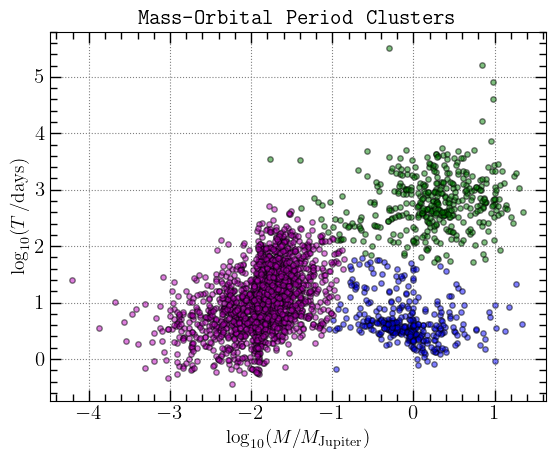

In [31]:
data = np.genfromtxt('Data/exoplanet-data-160824.csv',
                     usecols = (1,2), delimiter = ',', skip_header = 2)
# Filter out rows containing invalid values or values <= 0 and take log10.
data = data[~np.any(np.isnan(data), axis = 1)]
data = np.log10(data[np.all(data > 0, axis = 1)])

mu, clusters = kmeans_pp(data, 3, 5, True)
print('')
print('M / M(Jup) | T / days')
print('---------------------')
for row in 10**np.array(mu):
    print('{:8.4f}     {:6.2f}'.format(*row))

# Plot the clusters in distinct colours on a scatter plot.
fig, ax = plt.subplots()
colors = ['b', 'g', 'm']
for k, cluster in enumerate(clusters):
    log_mass, log_op = np.array(cluster).T
    ax.scatter(log_mass, log_op, c = colors[k], edgecolors = "black", alpha = 0.5, lw = 1, s = 15, zorder = 3)
    
ax.set_xlabel(r'$\log_{10}(M/M_{\mathrm{Jupiter}})$', fontsize = 14)
ax.set_ylabel(r'$\log_{10}(T\,/\mathrm{days})$', fontsize = 14)
ax.set_title('Mass-Orbital Period Clusters', fontsize = 16)

opt_plot()
plt.savefig('Plots/exoplanet-clustering.png', dpi = 400)
plt.show()

---